In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Create a sample dataset
np.random.seed(42)

df = pd.DataFrame({
    "Income": np.random.exponential(scale=50000, size=1000),
    "Age": np.random.normal(35, 8, 1000),
    "Experience": np.random.normal(10, 4, 1000),
    "Spending": np.random.exponential(scale=2000, size=1000),
    "Score": np.random.normal(70, 10, 1000)
})

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 5)


,Income,Age,Experience,Spending,Score
0,23463.404499,36.421608,4.374730,652.481266,61.680451
1,150506.071546,24.317245,9.667578,3201.880215,63.617173
2,65837.284677,38.041583,3.981119,789.803944,61.846244
3,45647.127689,39.884686,13.040224,711.588874,59.337651
4,8481.243523,39.478324,10.329759,529.249214,91.247714


In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns

print("Numerical Variables:")
print(list(numerical_cols))

Numerical Variables:
['Income', 'Age', 'Experience', 'Spending', 'Score']


In [8]:
results = []

for col in numerical_cols:
    results.append({
        "Variable": col,
        "Skewness": skew(df[col].dropna()),
        "Kurtosis": kurtosis(df[col].dropna())
    })

stats_df = pd.DataFrame(results)

stats_df

,Variable,Skewness,Kurtosis
0,Income,1.865034,5.217828
1,Age,-0.036663,-0.027124
2,Experience,0.001919,0.051512
3,Spending,2.063835,6.094154
4,Score,-0.046429,-0.061164


In [9]:
def skew_interpretation(value):
    if value > 1:
        return "Highly right-skewed"
    elif value < -1:
        return "Highly left-skewed"
    elif value > 0.5:
        return "Moderately right-skewed"
    elif value < -0.5:
        return "Moderately left-skewed"
    else:
        return "Approximately symmetric"

def kurtosis_interpretation(value):
    if value > 1:
        return "Heavy-tailed"
    elif value < -1:
        return "Light-tailed"
    else:
        return "Approximately normal-tailed"

stats_df["Skewness Interpretation"] = stats_df["Skewness"].apply(skew_interpretation)
stats_df["Kurtosis Interpretation"] = stats_df["Kurtosis"].apply(kurtosis_interpretation)

stats_df

,Variable,Skewness,Kurtosis,Skewness Interpretation,Kurtosis Interpretation
0,Income,1.865034,5.217828,Highly right-skewed,Heavy-tailed
1,Age,-0.036663,-0.027124,Approximately symmetric,Approximately normal-tailed
2,Experience,0.001919,0.051512,Approximately symmetric,Approximately normal-tailed
3,Spending,2.063835,6.094154,Highly right-skewed,Heavy-tailed
4,Score,-0.046429,-0.061164,Approximately symmetric,Approximately normal-tailed


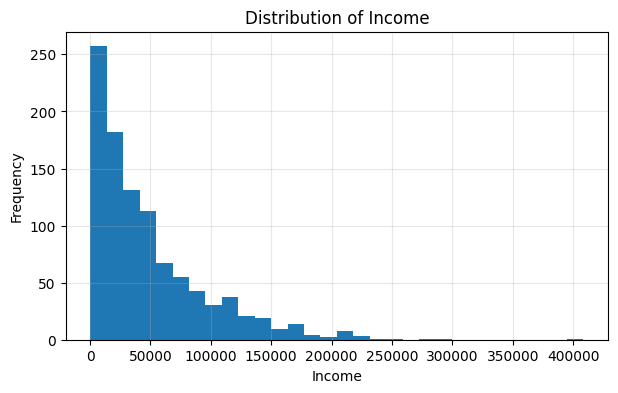

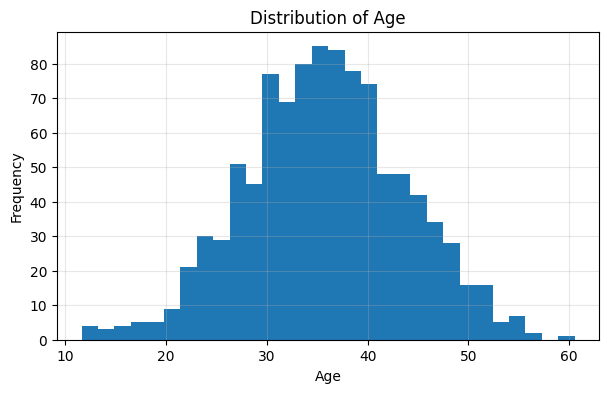

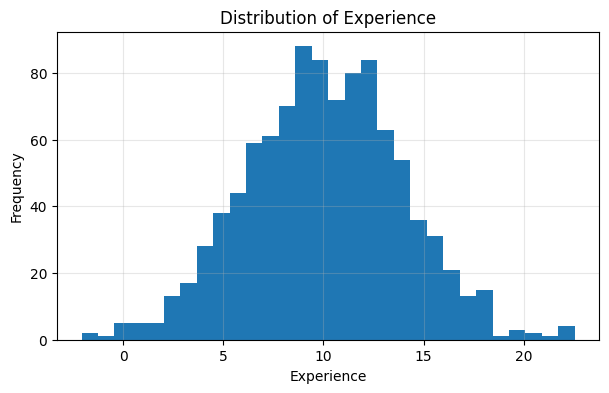

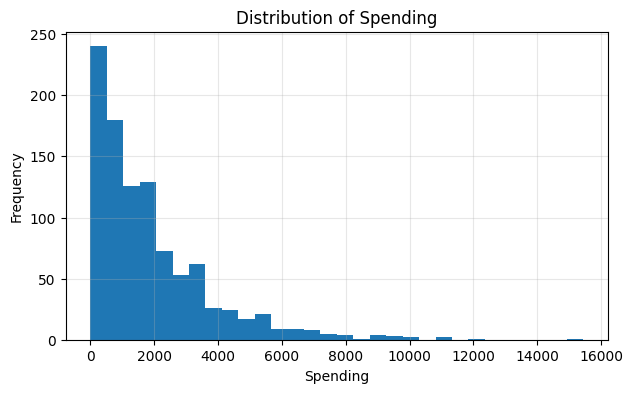

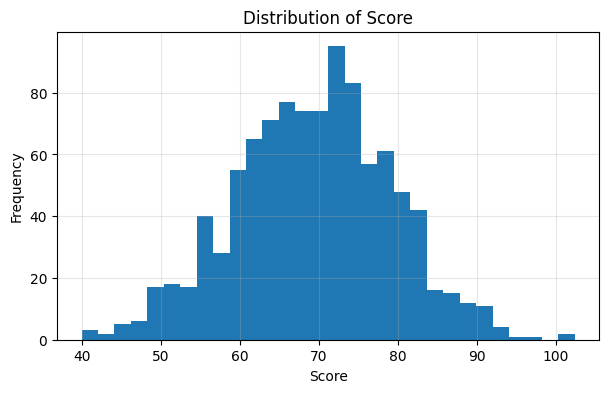

In [10]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

In [11]:
comparison = stats_df.sort_values(
    by="Skewness",
    key=lambda x: abs(x),
    ascending=False
)

comparison[["Variable", "Skewness", "Kurtosis"]]

,Variable,Skewness,Kurtosis
3,Spending,2.063835,6.094154
0,Income,1.865034,5.217828
4,Score,-0.046429,-0.061164
1,Age,-0.036663,-0.027124
2,Experience,0.001919,0.051512


In [12]:
most_skewed = stats_df.loc[
    stats_df["Skewness"].abs().idxmax()
]

print("Most skewed variable:", most_skewed["Variable"])
print("Skewness:", round(most_skewed["Skewness"], 3))
print("Kurtosis:", round(most_skewed["Kurtosis"], 3))
print("Interpretation:", most_skewed["Skewness Interpretation"])

Most skewed variable: Spending
Skewness: 2.064
Kurtosis: 6.094
Interpretation: Highly right-skewed


## Interpretation Report

Skewness measures the asymmetry of a data distribution around its mean.

- Skewness close to 0 indicates an approximately symmetric distribution.
- Positive skewness indicates a longer right tail.
- Negative skewness indicates a longer left tail.
- Large absolute skewness indicates a highly asymmetric distribution.

Kurtosis describes the tail heaviness and peakedness of a distribution.

- Kurtosis close to 0 indicates a distribution with approximately normal tails.
- Positive kurtosis indicates heavier tails and potentially more extreme values.
- Negative kurtosis indicates lighter tails.

The numerical analysis and distribution plots were used together to compare the shapes of different variables. Highly skewed variables may require transformation before being used in some machine learning models because extreme values can influence model performance.

Overall, skewness and kurtosis provide useful information about the distribution shape, presence of asymmetry, and potential extreme values in numerical variables.

## Interview Questions

### 1. What does skewness measure?
Skewness measures the asymmetry of a probability distribution around its mean.

### 2. What does kurtosis describe?
Kurtosis describes the heaviness of the tails and the presence of extreme values in a distribution.

### 3. Why can skewed features affect machine learning models?
Highly skewed features can contain extreme values and may negatively affect algorithms that are sensitive to feature scale and distribution. Transformations such as logarithmic transformation can sometimes reduce skewness.